# A2: Language Model

**by Dechathon Niamsa-ard [st126235]**

### Import necessary libraries

In [1]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import datasets
import math
import pickle
import time
import os
import matplotlib.pyplot as plt

from tqdm import tqdm
from datasets import DatasetDict

# Note: The torchtext library is deprecated and has been removed from modern PyTorch distributions. 
# My GPU (Nvidia RTX 5060 Ti) utilizes the Blackwell architecture, which requires a recent version of PyTorch (likely 2.7+) to function. 
# Since torchtext is not compatible with these newer PyTorch versions, 
# I cannot run the original lab environment and must migrate the data loading pipeline to a supported method.

# Define paths
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
MODEL_DIR = os.path.join(BASE_DIR, 'model')
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"Base Directory: {BASE_DIR}")
print(f"Model Directory: {MODEL_DIR}")

Base Directory: c:\Users\USER\Documents\Dechathon_N\AIT\Natural Language Understanding\A2 - Language Model\A2-Language-Model
Model Directory: c:\Users\USER\Documents\Dechathon_N\AIT\Natural Language Understanding\A2 - Language Model\A2-Language-Model\model


In [2]:
# ============================================================================
# Torchtext Compatibility Layer
# ============================================================================
# This module provides drop-in replacements for deprecated torchtext functions:
# - torchtext.data.utils.get_tokenizer -> get_tokenizer
# - torchtext.vocab.build_vocab_from_iterator -> build_vocab_from_iterator
# 
# Usage is identical to the original torchtext API.
# ============================================================================

import re
from collections import Counter

def _basic_english_tokenizer(text):
    """
    Tokenizer that mimics torchtext's basic_english tokenizer.
    - Lowercases text
    - Handles punctuation
    - Splits on whitespace
    """
    text = text.lower()
    # Add spaces around punctuation
    text = re.sub(r"([.,!?;:'\"\(\)\[\]\{\}])", r" \1 ", text)
    # Replace multiple spaces with single space
    text = re.sub(r"\s+", " ", text)
    # Split and filter empty strings
    tokens = [t for t in text.strip().split() if t]
    return tokens


# Torchtext-compatible namespace
class torchtext:
    """Compatibility layer for torchtext (deprecated library)"""
    
    class data:
        class utils:
            @staticmethod
            def get_tokenizer(name='basic_english'):
                """Returns a tokenizer function (compatible with torchtext.data.utils.get_tokenizer)"""
                if name == 'basic_english':
                    return _basic_english_tokenizer
                return lambda x: x.split()
    
    class vocab:
        class Vocab:
            """
            Custom vocabulary class compatible with torchtext.vocab.Vocab.
            """
            def __init__(self, counter, min_freq=1):
                self.itos = []  # index to string
                self.stoi = {}  # string to index
                self.default_index = 0
                
                # Build vocabulary from counter
                for token, freq in counter.most_common():
                    if freq >= min_freq:
                        self.stoi[token] = len(self.itos)
                        self.itos.append(token)
            
            def __len__(self):
                return len(self.itos)
            
            def __getitem__(self, token):
                """Get index for a token."""
                return self.stoi.get(token, self.default_index)
            
            def insert_token(self, token, index):
                """Insert a token at a specific index."""
                if token in self.stoi:
                    return
                # Shift existing tokens
                for t, i in list(self.stoi.items()):
                    if i >= index:
                        self.stoi[t] = i + 1
                self.stoi[token] = index
                self.itos.insert(index, token)
            
            def set_default_index(self, index):
                """Set the default index for unknown tokens."""
                self.default_index = index
            
            def get_itos(self):
                """Get index-to-string list."""
                return self.itos
        
        @staticmethod
        def build_vocab_from_iterator(iterator, min_freq=1):
            """
            Build vocabulary from an iterator of token lists.
            Compatible with torchtext.vocab.build_vocab_from_iterator.
            """
            counter = Counter()
            for tokens in iterator:
                counter.update(tokens)
            return torchtext.vocab.Vocab(counter, min_freq=min_freq)


# Create convenient aliases (same as original torchtext imports)
get_tokenizer = torchtext.data.utils.get_tokenizer
build_vocab_from_iterator = torchtext.vocab.build_vocab_from_iterator
Vocab = torchtext.vocab.Vocab

print("Torchtext compatibility layer loaded successfully!")
print("Available: get_tokenizer, build_vocab_from_iterator, Vocab")

Torchtext compatibility layer loaded successfully!
Available: get_tokenizer, build_vocab_from_iterator, Vocab


In [3]:
# Set device to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Version used by PyTorch: {torch.version.cuda}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")
print(f"GPU Capability: {torch.cuda.get_device_capability(0)}")
print(f'Using device: {device}')

PyTorch Version: 2.10.0+cu128
CUDA Version used by PyTorch: 12.8
GPU Name: NVIDIA GeForce RTX 5060 Ti
GPU Capability: (12, 0)
Using device: cuda


In [4]:
# Set random seed for reproducibility
SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

## Task 1. Dataset Acquisition
- Your first task is to find a suitable text dataset. (1 points)
1) Choose your dataset and provide a brief description. Ensure to source this dataset from reputable public databases or repositories. It is imperative to give proper credit to the dataset source in your documentation.

Note: The dataset can be based on any theme such as Harry Potter, Star Wars, jokes, Isaac Asimov’s works, Thai stories, etc. The key requirement is that the dataset should be text-rich and suitable for language modeling.

### Dataset Description: TinyStories 

**Dataset:** TinyStories (roneneldan/TinyStories)

**Source:** https://huggingface.co/datasets/roneneldan/TinyStories

---

#### About the Original Dataset

TinyStories is a synthetic dataset created by Microsoft Research, designed to answer an interesting question: *"How small can language models be and still speak coherent English?"* 

The researchers generated millions of short stories using GPT-3.5 and GPT-4, but with a unique constraint — all stories use only vocabulary that a typical 3-4 year old child would understand. Despite this simple vocabulary, the stories maintain proper grammar, logical flow, and narrative structure with clear beginnings, middles, and endings.

**Original Dataset Statistics:**

| Split | Number of Stories |
|-------|-------------------|
| Training | 2,119,719 |
| Validation | 21,990 |

Each story is typically 50-200 words long and covers child-friendly themes like friendship, family, animals, and simple adventures.

---

#### Why I Chose This Dataset

For this language modeling assignment, I wanted a dataset that would:
1. Be text-rich with consistent narrative structure
2. Have clean, grammatically correct text (no noisy web scrapes)
3. Be manageable for training on my hardware

TinyStories fits perfectly — the clean synthetic data means my LSTM model can focus on learning language patterns without being confused by typos, slang, or inconsistent formatting that you'd find in web-scraped datasets.

---

#### My Subset for This Assignment

Due to hardware and time constraints, I use a subset of the full dataset:

| Split | Original Size | My Subset |
|-------|---------------|-----------|
| Training | 2,119,719 | 100,000 |
| Validation | 21,990 | ~11,000 (first half) |
| Test | — | ~11,000 (second half) |

I split the original validation set into two parts to create both validation and test sets, ensuring I have held-out data for final evaluation that the model never sees during training or hyperparameter tuning.

---

#### Citation

```BibTeX
@misc{eldan2023tinystoriessmalllanguagemodels,
      title={TinyStories: How Small Can Language Models Be and Still Speak Coherent English?}, 
      author={Ronen Eldan and Yuanzhi Li},
      year={2023},
      eprint={2305.07759},
      archivePrefix={arXiv},
      primaryClass={cs.CL},
      url={https://arxiv.org/abs/2305.07759}, 
}
```

**Paper:** https://arxiv.org/abs/2305.07759

In [5]:
# Load the TinyStories dataset from datasets
dataset = datasets.load_dataset("roneneldan/TinyStories")

In [6]:
# Display the dataset structure
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 2119719
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 21990
    })
})


In [7]:
# Display sample stories from dataset
print("Sample Story from TinyStories dataset:")
print(dataset['train'][0]['text'][:500])
print(f"\nTotal training samples: {len(dataset['train']):,}")
print(f"Total validation samples: {len(dataset['validation']):,}")

# Note: I will use the subset for faster experimentation due to hardware constraints.
# Including training subset of 100,000 samples, validation subset of 10,995 samples and test subset of 10,995 samples

Sample Story from TinyStories dataset:
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them b

Total training samples: 2,119,719
Total validation samples: 21,990


## Task 2. Model Training
- Incorporate the chosen dataset into our existing code framework. Train a language model that can understand the context and style of the text.
1) Detail the steps taken to preprocess the text data. (1 points)
2) Describe the model architecture and the training process. (1 points)

### Preprocessing the Text Data

Before feeding text into the neural network, I need to transform raw stories into numerical sequences. Here's how I approached each preprocessing step:

---

#### Step 1: Tokenization

I use a basic English tokenizer that converts each story into a list of tokens. The tokenizer lowercases all text and separates punctuation from words. For example, `"Hello, world!"` becomes `['hello', ',', 'world', '!']`. 

Since `torchtext` is deprecated in newer PyTorch versions (which I need for my RTX 5060 Ti GPU), I implemented a compatible tokenizer that replicates the same behavior.

#### Step 2: Building the Vocabulary

From the tokenized training data, I build a vocabulary — a mapping between words and integer indices. I set `min_freq=3`, meaning only words appearing at least 3 times are included. This reduces the vocabulary size and filters out rare words or typos.

#### Step 3: Special Tokens

I add two special tokens:
- `<unk>` (index 0): Represents any word not in the vocabulary
- `<eos>` (index 1): Marks the end of each story, helping the model learn when to stop generating

#### Step 4: Numericalization

Each token is converted to its corresponding integer index. Unknown words map to `<unk>`. This transforms text into sequences of numbers the model can process.

#### Step 5: Batching

Finally, I organize all token indices into a contiguous tensor and reshape it for batch processing. The data is arranged so that each batch contains parallel sequences, allowing the LSTM to maintain hidden states across batches efficiently.

In [8]:
# Step 1: Tokenization
# Using custom basic_english tokenizer (replacement for torchtext)
tokenizer = get_tokenizer('basic_english')

# Tokenize the dataset
def tokenize_data(example):
    return {'tokens': tokenizer(example['text'])}

# Create subsets for faster training
# We'll use 100,000 samples from training for efficiency
# Split validation into validation (10,995) and test (10,995) sets
train_subset = dataset['train'].select(range(min(100000, len(dataset['train']))))

val_size = len(dataset['validation'])
val_subset = dataset['validation'].select(range(val_size // 2))
test_subset = dataset['validation'].select(range(val_size // 2, val_size))

# Create a DatasetDict to organize all splits

dataset_splits = DatasetDict({
    'train': train_subset,
    'validation': val_subset,
    'test': test_subset
})

print("Dataset Splits (DatasetDict):")
print(dataset_splits)

# Apply tokenization to all splits at once using DatasetDict
tokenized_datasets = dataset_splits.map(
    tokenize_data, 
    remove_columns=['text'],
    desc="Tokenizing"
)

print("\nTokenized Dataset Splits:")
print(tokenized_datasets)
print(f"\nTokenized training samples: {len(tokenized_datasets['train'])}")
print(f"Tokenized validation samples: {len(tokenized_datasets['validation'])}")
print(f"Tokenized test samples: {len(tokenized_datasets['test'])}")
print(f"\nSample tokenized text: {tokenized_datasets['train'][0]['tokens'][:20]}...")

Dataset Splits (DatasetDict):
DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 100000
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 10995
    })
    test: Dataset({
        features: ['text'],
        num_rows: 10995
    })
})

Tokenized Dataset Splits:
DatasetDict({
    train: Dataset({
        features: ['tokens'],
        num_rows: 100000
    })
    validation: Dataset({
        features: ['tokens'],
        num_rows: 10995
    })
    test: Dataset({
        features: ['tokens'],
        num_rows: 10995
    })
})

Tokenized training samples: 100000
Tokenized validation samples: 10995
Tokenized test samples: 10995

Sample tokenized text: ['one', 'day', ',', 'a', 'little', 'girl', 'named', 'lily', 'found', 'a', 'needle', 'in', 'her', 'room', '.', 'she', 'knew', 'it', 'was', 'difficult']...


In [9]:
# Step 2: Build Vocabulary
# Add words that appear at least 3 times to keep vocabulary manageable
# Build vocabulary from training split only
vocab = build_vocab_from_iterator(tokenized_datasets['train']['tokens'], min_freq=3)

# Step 3: Add special tokens
vocab.insert_token('<unk>', 0)  # Unknown token
vocab.insert_token('<eos>', 1)  # End of sequence token
vocab.set_default_index(vocab['<unk>'])

print(f"Vocabulary size: {len(vocab)}")
print(f"First 20 tokens in vocabulary: {vocab.get_itos()[:20]}")

Vocabulary size: 12615
First 20 tokens in vocabulary: ['<unk>', '<eos>', '.', 'the', 'and', ',', 'to', 'a', 'was', '"', 'he', 'she', 'it', 'they', 'her', "'", 'said', '!', 'in', 'his']


In [10]:
# Step 4 & 5: Prepare data for batching
def get_data(tokenized_dataset, vocab, batch_size):
    """
    Convert tokenized dataset into batched tensor format.
    Each batch contains a contiguous sequence of tokens.
    """
    data = []
    for example in tokenized_dataset:
        if example['tokens']:
            # Add end of sequence token
            tokens = example['tokens'] + ['<eos>']
            # Convert tokens to indices
            indices = [vocab[token] for token in tokens]
            data.extend(indices)
    
    data = torch.LongTensor(data)
    num_batches = data.shape[0] // batch_size
    data = data[:num_batches * batch_size]
    data = data.view(batch_size, num_batches)
    return data  # Shape: [batch_size, seq_len]

# Prepare batched data from DatasetDict
batch_size = 64
train_data = get_data(tokenized_datasets['train'], vocab, batch_size)
valid_data = get_data(tokenized_datasets['validation'], vocab, batch_size)
test_data = get_data(tokenized_datasets['test'], vocab, batch_size)

print(f"Training data shape: {train_data.shape}")
print(f"Validation data shape: {valid_data.shape}")
print(f"Test data shape: {test_data.shape}")

Training data shape: torch.Size([64, 326704])
Validation data shape: torch.Size([64, 33774])
Test data shape: torch.Size([64, 37151])


### Model Architecture

For this assignment, I implemented an LSTM-based language model. I chose LSTM over vanilla RNN because it handles long-range dependencies better through its gating mechanisms, which helps when generating coherent multi-sentence stories.

---

#### Why LSTM?

Standard RNNs suffer from the vanishing gradient problem — when backpropagating through many time steps, gradients become extremely small, making it hard to learn long-term dependencies. LSTM solves this with a **cell state** that acts as a highway for information to flow unchanged, plus **three gates** that control what information to keep, forget, or output.

---

#### LSTM Gates Explained

For each time step $t$, the LSTM computes:

**1. Forget Gate** — decides what to discard from the cell state:
$$\mathbf{f}_t = \sigma(\mathbf{W}_f \mathbf{h}_{t-1} + \mathbf{U}_f \mathbf{x}_t + \mathbf{b}_f)$$

**2. Input Gate** — decides what new information to store:
$$\mathbf{i}_t = \sigma(\mathbf{W}_i \mathbf{h}_{t-1} + \mathbf{U}_i \mathbf{x}_t + \mathbf{b}_i)$$

**3. Candidate Cell State** — creates new candidate values:
$$\mathbf{g}_t = \tanh(\mathbf{W}_g \mathbf{h}_{t-1} + \mathbf{U}_g \mathbf{x}_t + \mathbf{b}_g)$$

**4. Cell State Update** — combines old state with new candidates:
$$\mathbf{c}_t = \mathbf{f}_t \odot \mathbf{c}_{t-1} + \mathbf{i}_t \odot \mathbf{g}_t$$

**5. Output Gate** — decides what to output:
$$\mathbf{o}_t = \sigma(\mathbf{W}_o \mathbf{h}_{t-1} + \mathbf{U}_o \mathbf{x}_t + \mathbf{b}_o)$$

**6. Hidden State** — the final output for this time step:
$$\mathbf{h}_t = \mathbf{o}_t \odot \tanh(\mathbf{c}_t)$$

Where $\odot$ is element-wise multiplication, $\sigma$ is the sigmoid function, and $\mathbf{W}$, $\mathbf{U}$, $\mathbf{b}$ are learnable parameters.

---

#### My Architecture

My model stacks these components:

1. **Embedding Layer:** Converts each token index into a 512-dimensional dense vector. These embeddings are learned during training and capture semantic relationships between words.

2. **LSTM Layers (×2):** I stack 2 LSTM layers with 512 hidden units each. Stacking allows the model to learn hierarchical representations — the first layer might capture word-level patterns while the second captures phrase-level patterns.

3. **Dropout (0.5):** Applied after embedding and after LSTM output. This randomly zeros out 50% of activations during training, forcing the model to not rely on any single feature and improving generalization.

4. **Output Layer:** A linear layer that projects the 512-dimensional hidden states to vocabulary size, producing a score (logit) for each possible next token.

#### Model Configuration

| Parameter | Value |
|-----------|-------|
| Embedding Dimension | 512 |
| Hidden Dimension | 512 |
| LSTM Layers | 2 |
| Dropout Rate | 0.5 |
| Total Parameters | ~19.6M |

In [11]:
class LSTMLanguageModel(nn.Module):
    """
    LSTM-based Language Model for text generation.
    
    Architecture:
    - Embedding layer: Maps token indices to dense vectors
    - Multi-layer LSTM: Captures sequential dependencies
    - Dropout: Regularization
    - Linear layer: Projects to vocabulary size for next-token prediction
    """
    def __init__(self, vocab_size, emb_dim, hid_dim, num_layers, dropout_rate):
        super().__init__()
        self.num_layers = num_layers
        self.hid_dim = hid_dim
        self.emb_dim = emb_dim
        
        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        
        # LSTM layers
        self.lstm = nn.LSTM(emb_dim, hid_dim, num_layers=num_layers, 
                           dropout=dropout_rate, batch_first=True)
        
        # Regularization
        self.dropout = nn.Dropout(dropout_rate)
        
        # Output projection
        self.fc = nn.Linear(hid_dim, vocab_size)
        
        self.init_weights()
    
    def init_weights(self):
        """Initialize weights with uniform distribution."""
        init_range_emb = 0.1
        init_range_other = 1 / math.sqrt(self.hid_dim)
        
        self.embedding.weight.data.uniform_(-init_range_emb, init_range_emb)
        self.fc.weight.data.uniform_(-init_range_other, init_range_other)
        self.fc.bias.data.zero_()
        
        for i in range(self.num_layers):
            self.lstm.all_weights[i][0] = torch.FloatTensor(
                self.emb_dim, self.hid_dim).uniform_(-init_range_other, init_range_other)
            self.lstm.all_weights[i][1] = torch.FloatTensor(
                self.hid_dim, self.hid_dim).uniform_(-init_range_other, init_range_other)
    
    def init_hidden(self, batch_size, device):
        """Initialize hidden state and cell state with zeros."""
        hidden = torch.zeros(self.num_layers, batch_size, self.hid_dim).to(device)
        cell = torch.zeros(self.num_layers, batch_size, self.hid_dim).to(device)
        return hidden, cell
    
    def detach_hidden(self, hidden):
        """Detach hidden states from computation graph for TBPTT."""
        hidden, cell = hidden
        hidden = hidden.detach()
        cell = cell.detach()
        return hidden, cell
    
    def forward(self, src, hidden):
        """
        Forward pass.
        
        Args:
            src: Input tensor [batch_size, seq_len]
            hidden: Tuple of (hidden_state, cell_state)
        
        Returns:
            prediction: Output logits [batch_size, seq_len, vocab_size]
            hidden: Updated hidden states
        """
        # Embed input tokens
        embedding = self.dropout(self.embedding(src))
        # [batch_size, seq_len, emb_dim]
        
        # Pass through LSTM
        output, hidden = self.lstm(embedding, hidden)
        # output: [batch_size, seq_len, hid_dim]
        
        # Apply dropout and project to vocabulary
        output = self.dropout(output)
        prediction = self.fc(output)
        # prediction: [batch_size, seq_len, vocab_size]
        
        return prediction, hidden

In [12]:
# Model hyperparameters
vocab_size = len(vocab)
emb_dim = 512          # Embedding dimension
hid_dim = 512          # Hidden dimension
num_layers = 2         # Number of LSTM layers
dropout_rate = 0.5     # Dropout rate
lr = 1e-3              # Learning rate

# Initialize model, optimizer, and loss function
model = LSTMLanguageModel(vocab_size, emb_dim, hid_dim, num_layers, dropout_rate).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

# Count trainable parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model Architecture:")
print(f"{'='*50}")
print(f"Vocabulary Size: {vocab_size:,}")
print(f"Embedding Dimension: {emb_dim}")
print(f"Hidden Dimension: {hid_dim}")
print(f"Number of LSTM Layers: {num_layers}")
print(f"Dropout Rate: {dropout_rate}")
print(f"{'='*50}")
print(f"Total Trainable Parameters: {num_params:,}")

Model Architecture:
Vocabulary Size: 12,615
Embedding Dimension: 512
Hidden Dimension: 512
Number of LSTM Layers: 2
Dropout Rate: 0.5
Total Trainable Parameters: 17,132,871


### Training Process

I train the model to predict the next token given all previous tokens — the standard language modeling objective. Here's my training approach:

---

#### Training Configuration

| Setting | Value | Reason |
|---------|-------|--------|
| Epochs | 20 | Sufficient for convergence on this dataset size |
| Sequence Length | 50 | Balance between context and memory usage |
| Batch Size | 64 | Fits comfortably in GPU memory |
| Learning Rate | 0.001 | Standard starting point for Adam |
| Gradient Clipping | 0.25 | Prevents exploding gradients in RNNs |

#### Key Techniques

**Truncated Backpropagation Through Time (TBPTT):** Instead of backpropagating through entire stories (which would be computationally expensive), I process sequences in chunks of 50 tokens. Hidden states carry forward between chunks, but gradients only flow within each chunk.

**Learning Rate Scheduling:** I use `ReduceLROnPlateau` scheduler — if validation loss doesn't improve for 1 epoch, the learning rate is halved. This helps fine-tune the model as training progresses.

**Model Checkpointing:** I save the model weights whenever validation loss improves. This ensures I keep the best-performing model rather than the final (potentially overfit) one.

#### Evaluation Metric

I evaluate using **perplexity**, which is the exponentiated cross-entropy loss:

$$\text{Perplexity} = e^{\text{loss}}$$

Lower perplexity means the model is more confident in its predictions. A perplexity of 50 means the model is, on average, as uncertain as if it were choosing uniformly among 50 options.

In [13]:
def get_batch(data, seq_len, idx):
    """
    Get a batch of data for training/evaluation.
    
    Args:
        data: Full data tensor [batch_size, total_seq_len]
        seq_len: Length of sequence to extract
        idx: Starting index
    
    Returns:
        src: Input sequence [batch_size, seq_len]
        target: Target sequence (shifted by 1) [batch_size, seq_len]
    """
    src = data[:, idx:idx+seq_len]
    target = data[:, idx+1:idx+seq_len+1]
    return src, target


def train(model, data, optimizer, criterion, batch_size, seq_len, clip, device):
    """
    Train the model for one epoch.
    
    Args:
        model: The LSTM language model
        data: Training data
        optimizer: Optimizer
        criterion: Loss function
        batch_size: Batch size
        seq_len: Sequence length for TBPTT
        clip: Gradient clipping threshold
        device: Device to use
    
    Returns:
        Average loss per token
    """
    epoch_loss = 0
    model.train()
    
    num_batches = data.shape[-1]
    data = data[:, :num_batches - (num_batches - 1) % seq_len]
    num_batches = data.shape[-1]
    
    # Reset hidden state at the start of each epoch
    hidden = model.init_hidden(batch_size, device)
    
    for idx in tqdm(range(0, num_batches - 1, seq_len), desc='Training', leave=False):
        optimizer.zero_grad()
        
        # Detach hidden state to avoid backprop through entire history
        hidden = model.detach_hidden(hidden)
        
        src, target = get_batch(data, seq_len, idx)
        src, target = src.to(device), target.to(device)
        batch_size = src.shape[0]
        
        prediction, hidden = model(src, hidden)
        
        # Reshape for loss calculation
        prediction = prediction.reshape(batch_size * seq_len, -1)
        target = target.reshape(-1)
        
        loss = criterion(prediction, target)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        
        epoch_loss += loss.item() * seq_len
    
    return epoch_loss / num_batches


def evaluate(model, data, criterion, batch_size, seq_len, device):
    """
    Evaluate the model on validation/test data.
    
    Returns:
        Average loss per token
    """
    epoch_loss = 0
    model.eval()
    
    num_batches = data.shape[-1]
    data = data[:, :num_batches - (num_batches - 1) % seq_len]
    num_batches = data.shape[-1]
    
    hidden = model.init_hidden(batch_size, device)
    
    with torch.no_grad():
        for idx in range(0, num_batches - 1, seq_len):
            hidden = model.detach_hidden(hidden)
            src, target = get_batch(data, seq_len, idx)
            src, target = src.to(device), target.to(device)
            batch_size = src.shape[0]
            
            prediction, hidden = model(src, hidden)
            prediction = prediction.reshape(batch_size * seq_len, -1)
            target = target.reshape(-1)
            
            loss = criterion(prediction, target)
            epoch_loss += loss.item() * seq_len
    
    return epoch_loss / num_batches

In [14]:
# Training configuration
n_epochs = 20          # Number of training epochs
seq_len = 50           # Sequence length for TBPTT
clip = 0.25            # Gradient clipping threshold

# Path for saving best model
best_model_path = os.path.join(BASE_DIR, 'best-val-lstm_lm.pt')

# Learning rate scheduler - reduce LR when validation loss plateaus
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=1)

best_valid_loss = float('inf')

# Lists to store metrics for plotting
train_losses = []
valid_losses = []
train_perplexities = []
valid_perplexities = []
learning_rates = []
epoch_times = []

print("Starting Training...")
print("="*60)
print(f"Best model will be saved to: {best_model_path}")
print("="*60)

total_start_time = time.time()

for epoch in range(n_epochs):
    epoch_start_time = time.time()
    
    train_loss = train(model, train_data, optimizer, criterion, 
                      batch_size, seq_len, clip, device)
    valid_loss = evaluate(model, valid_data, criterion, batch_size, 
                         seq_len, device)
    
    epoch_end_time = time.time()
    epoch_duration = epoch_end_time - epoch_start_time
    
    lr_scheduler.step(valid_loss)
    
    # Store metrics
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    train_perplexities.append(math.exp(train_loss))
    valid_perplexities.append(math.exp(valid_loss))
    learning_rates.append(optimizer.param_groups[0]["lr"])
    epoch_times.append(epoch_duration)
    
    # Save best model
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), best_model_path)
    
    print(f'Epoch {epoch+1:02d}/{n_epochs} | Time: {epoch_duration:.2f}s')
    print(f'\tTrain Loss: {train_loss:.4f} | Train Perplexity: {math.exp(train_loss):.3f}')
    print(f'\tValid Loss: {valid_loss:.4f} | Valid Perplexity: {math.exp(valid_loss):.3f}')
    print(f'\tLearning Rate: {optimizer.param_groups[0]["lr"]:.6f}')

total_end_time = time.time()
total_training_time = total_end_time - total_start_time

print("="*60)
print("Training Complete!")
print(f"Total Training Time: {total_training_time:.2f}s ({total_training_time/60:.2f} minutes)")
print(f"Average Time per Epoch: {sum(epoch_times)/len(epoch_times):.2f}s")

Starting Training...
Best model will be saved to: c:\Users\USER\Documents\Dechathon_N\AIT\Natural Language Understanding\A2 - Language Model\A2-Language-Model\best-val-lstm_lm.pt


Epoch 01/20 | Time: 164.96s
	Train Loss: 3.3400 | Train Perplexity: 28.219
	Valid Loss: 2.7195 | Valid Perplexity: 15.173
	Learning Rate: 0.001000


Epoch 02/20 | Time: 166.27s
	Train Loss: 2.8162 | Train Perplexity: 16.714
	Valid Loss: 2.5228 | Valid Perplexity: 12.463
	Learning Rate: 0.001000


Epoch 03/20 | Time: 165.42s
	Train Loss: 2.6915 | Train Perplexity: 14.753
	Valid Loss: 2.4294 | Valid Perplexity: 11.352
	Learning Rate: 0.001000


Epoch 04/20 | Time: 165.10s
	Train Loss: 2.6199 | Train Perplexity: 13.734
	Valid Loss: 2.3689 | Valid Perplexity: 10.685
	Learning Rate: 0.001000


...

Epoch 16/20 | Time: 165.45s
	Train Loss: 2.3789 | Train Perplexity: 10.793
	Valid Loss: 2.1517 | Valid Perplexity: 8.599
	Learning Rate: 0.001000


Epoch 17/20 | Time: 164.45s
	Train Loss: 2.3709 | Train Perplexity: 10.707
	Valid Loss: 2.1449 | Valid Perplexity: 8.541
	Learning Rate: 0.001000


Epoch 18/20 | Time: 167.43s
	Train Loss: 2.3635 | Train Perplexity: 10.628
	Valid Loss: 2.1397 | Valid Perplexity: 8.497
	Learning Rate: 0.001000


Epoch 19/20 | Time: 167.93s
	Train Loss: 2.3562 | Train Perplexity: 10.551
	Valid Loss: 2.1333 | Valid Perplexity: 8.443
	Learning Rate: 0.001000


Epoch 20/20 | Time: 165.63s
	Train Loss: 2.3498 | Train Perplexity: 10.484
	Valid Loss: 2.1275 | Valid Perplexity: 8.394
	Learning Rate: 0.001000
Training Complete!
Total Training Time: 3317.91s (55.30 minutes)
Average Time per Epoch: 165.83s


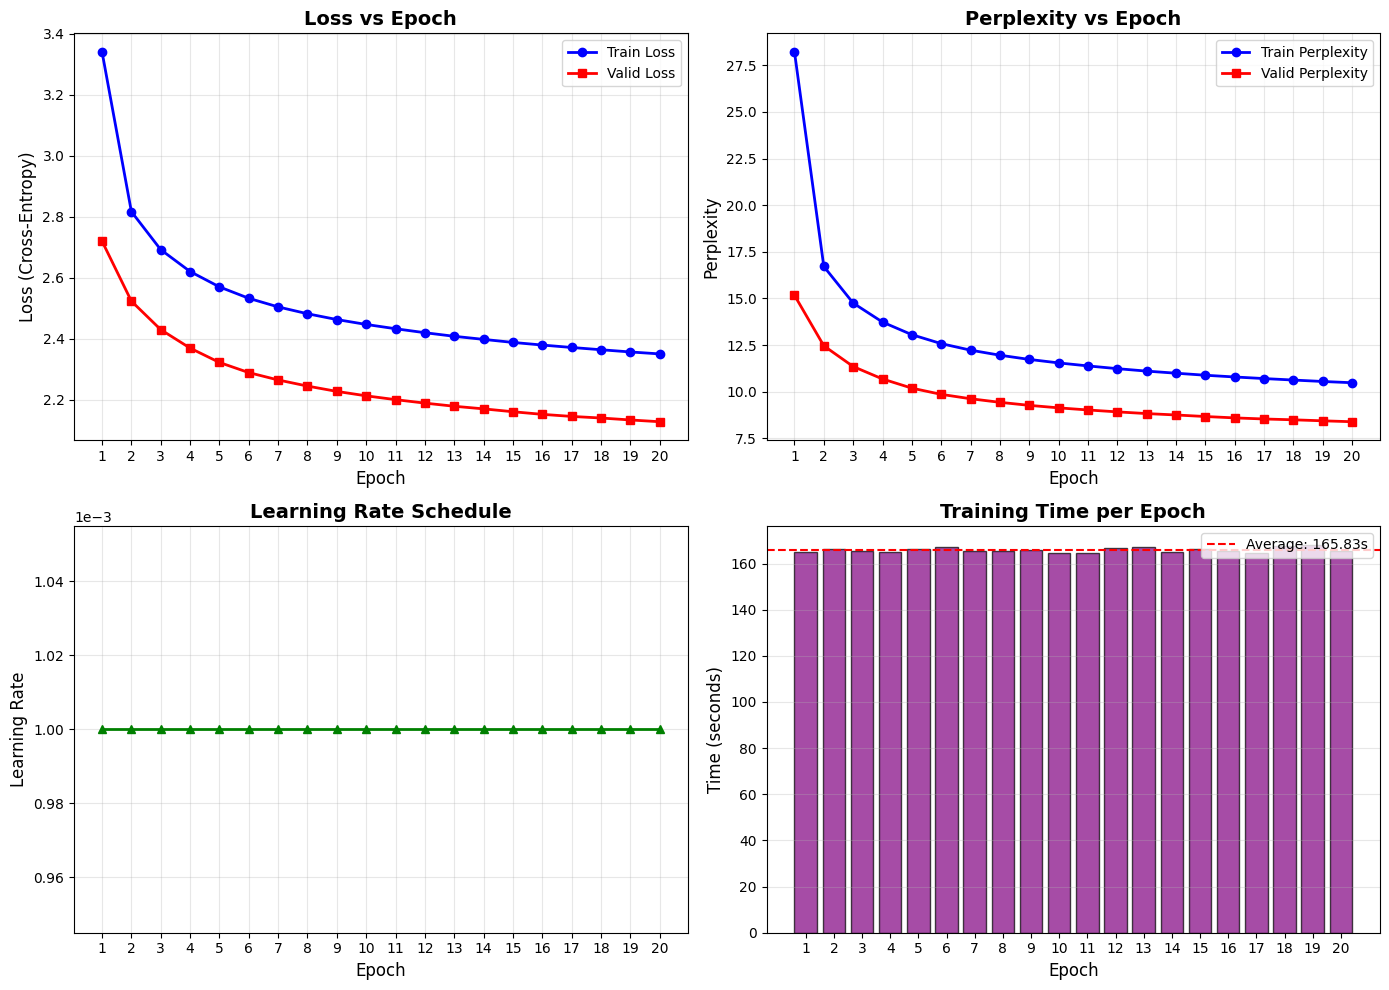


TRAINING SUMMARY
Epoch   Train Loss    Valid Loss    Train PPL     Valid PPL     Time (s)  
--------------------------------------------------------------------------------
1       3.3400        2.7195        28.22         15.17         164.96    
2       2.8162        2.5228        16.71         12.46         166.27    
3       2.6915        2.4294        14.75         11.35         165.42    
4       2.6199        2.3689        13.73         10.69         165.10    
5       2.5695        2.3218        13.06         10.19         166.43    
6       2.5321        2.2885        12.58         9.86          166.95    
7       2.5039        2.2644        12.23         9.63          165.33    
8       2.4814        2.2443        11.96         9.43          165.45    
9       2.4624        2.2269        11.73         9.27          165.77    
10      2.4464        2.2124        11.55         9.14          164.67    
11      2.4323        2.1999        11.39         9.02          164.39    
1

In [15]:
# Plot Training Metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs_range = range(1, n_epochs + 1)

# Plot 1: Loss vs Epoch
ax1 = axes[0, 0]
ax1.plot(epochs_range, train_losses, 'b-o', label='Train Loss', linewidth=2, markersize=6)
ax1.plot(epochs_range, valid_losses, 'r-s', label='Valid Loss', linewidth=2, markersize=6)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss (Cross-Entropy)', fontsize=12)
ax1.set_title('Loss vs Epoch', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(epochs_range)

# Plot 2: Perplexity vs Epoch
ax2 = axes[0, 1]
ax2.plot(epochs_range, train_perplexities, 'b-o', label='Train Perplexity', linewidth=2, markersize=6)
ax2.plot(epochs_range, valid_perplexities, 'r-s', label='Valid Perplexity', linewidth=2, markersize=6)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Perplexity', fontsize=12)
ax2.set_title('Perplexity vs Epoch', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(epochs_range)

# Plot 3: Learning Rate vs Epoch
ax3 = axes[1, 0]
ax3.plot(epochs_range, learning_rates, 'g-^', linewidth=2, markersize=6)
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('Learning Rate', fontsize=12)
ax3.set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_xticks(epochs_range)
ax3.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Plot 4: Time per Epoch
ax4 = axes[1, 1]
ax4.bar(epochs_range, epoch_times, color='purple', alpha=0.7, edgecolor='black')
ax4.axhline(y=sum(epoch_times)/len(epoch_times), color='red', linestyle='--', 
            label=f'Average: {sum(epoch_times)/len(epoch_times):.2f}s')
ax4.set_xlabel('Epoch', fontsize=12)
ax4.set_ylabel('Time (seconds)', fontsize=12)
ax4.set_title('Training Time per Epoch', fontsize=14, fontweight='bold')
ax4.legend(loc='upper right', fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_xticks(epochs_range)

plt.tight_layout()
plt.savefig('assets/training_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print("\n" + "="*80)
print("TRAINING SUMMARY")
print("="*80)
print(f"{'Epoch':<8}{'Train Loss':<14}{'Valid Loss':<14}{'Train PPL':<14}{'Valid PPL':<14}{'Time (s)':<10}")
print("-"*80)
for i in range(n_epochs):
    print(f"{i+1:<8}{train_losses[i]:<14.4f}{valid_losses[i]:<14.4f}{train_perplexities[i]:<14.2f}{valid_perplexities[i]:<14.2f}{epoch_times[i]:<10.2f}")
print("="*80)
print(f"Best Validation Loss: {min(valid_losses):.4f} (Epoch {valid_losses.index(min(valid_losses)) + 1})")
print(f"Best Validation Perplexity: {min(valid_perplexities):.2f}")
print(f"Total Training Time: {sum(epoch_times):.2f}s ({sum(epoch_times)/60:.2f} minutes)")

In [16]:
# Load best model and evaluate on validation and test sets
model.load_state_dict(torch.load(best_model_path, map_location=device))
print(f"Loaded best model from: {best_model_path}")

# Evaluate on validation set
final_valid_loss = evaluate(model, valid_data, criterion, batch_size, seq_len, device)
print(f'Final Validation Loss: {final_valid_loss:.4f}')
print(f'Final Validation Perplexity: {math.exp(final_valid_loss):.3f}')

# Evaluate on test set
test_loss = evaluate(model, test_data, criterion, batch_size, seq_len, device)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Perplexity: {math.exp(test_loss):.3f}')

Loaded best model from: c:\Users\USER\Documents\Dechathon_N\AIT\Natural Language Understanding\A2 - Language Model\A2-Language-Model\best-val-lstm_lm.pt
Final Validation Loss: 2.1275
Final Validation Perplexity: 8.394
Test Loss: 2.0943
Test Perplexity: 8.120


### Create Text Generation Funciton

The generation process works as follows:
1. Tokenize and encode the input prompt
2. Feed the encoded prompt through the model
3. Sample from the output probability distribution
4. Add the sampled token to the sequence
5. Repeat until `<eos>` token or max length reached

**Temperature Parameter:**
- Lower temperature (e.g., 0.5): More deterministic, safer predictions
- Higher temperature (e.g., 1.0): More diverse, creative outputs

In [17]:
def generate(prompt, max_seq_len, temperature, model, tokenizer, vocab, device, seed=None):
    """
    Generate text continuation from a given prompt.
    
    Args:
        prompt: Input text prompt
        max_seq_len: Maximum number of tokens to generate
        temperature: Sampling temperature (lower = more deterministic)
        model: The trained language model
        tokenizer: Tokenizer function
        vocab: Vocabulary object
        device: Device to use
        seed: Random seed for reproducibility
    
    Returns:
        List of generated tokens
    """
    if seed is not None:
        torch.manual_seed(seed)
    
    model.eval()
    tokens = tokenizer(prompt)
    indices = [vocab[t] for t in tokens]
    batch_size = 1
    hidden = model.init_hidden(batch_size, device)
    
    with torch.no_grad():
        for i in range(max_seq_len):
            src = torch.LongTensor([indices]).to(device)
            prediction, hidden = model(src, hidden)
            
            # Get probabilities for the last token
            probs = torch.softmax(prediction[:, -1] / temperature, dim=-1)
            
            # Sample from the distribution
            prediction = torch.multinomial(probs, num_samples=1).item()
            
            # Skip unknown tokens
            while prediction == vocab['<unk>']:
                prediction = torch.multinomial(probs, num_samples=1).item()
            
            # Stop at end of sequence
            if prediction == vocab['<eos>']:
                break
            
            # Add prediction to sequence (autoregressive)
            indices.append(prediction)
    
    # Convert indices back to tokens
    itos = vocab.get_itos()
    tokens = [itos[i] for i in indices]
    return tokens

In [18]:
# Test text generation with different temperatures
prompt = 'Once upon a time'
max_seq_len = 50
seed = 42

print("Text Generation Examples")
print("="*60)
print(f"Prompt: '{prompt}'")
print("="*60)

temperatures = [0.5, 0.7, 0.8, 1.0]
for temperature in temperatures:
    generation = generate(prompt, max_seq_len, temperature, model, tokenizer, 
                         vocab, device, seed)
    generated_text = ' '.join(generation)
    print(f"\nTemperature: {temperature}")
    print(f"Generated: {generated_text}")
    print("-"*60)

Text Generation Examples
Prompt: 'Once upon a time'

Temperature: 0.5
Generated: once upon a time . the little girl was so excited to see the fun , she said goodbye to the big one and went home .
------------------------------------------------------------

Temperature: 0.7
Generated: once upon a time . in the living room , there was a smart cat named fluffy . fluffy was curious and wanted to know what was inside . fluffy wanted to help the cat . " wow , can you help me ? " she asked . " i don ' t know
------------------------------------------------------------

Temperature: 0.8
Generated: once upon a time . in the living room , there was a smart cat named fluffy . fluffy was curious and wanted to know what was inside the box . she pushed the mouse in the air and made a funny noise . " hey , fluffy ! " lily said . "
------------------------------------------------------------

Temperature: 1.0
Generated: once upon a time . in the living room , there was a smart cat named fluffy . fluf

In [19]:
# Save the model and vocabulary for the web application
model_save_path = os.path.join(MODEL_DIR, 'lstm_lm_complete.pt')
vocab_save_path = os.path.join(MODEL_DIR, 'vocab.pkl')

torch.save({
    'model_state_dict': model.state_dict(),
    'vocab_size': vocab_size,
    'emb_dim': emb_dim,
    'hid_dim': hid_dim,
    'num_layers': num_layers,
    'dropout_rate': dropout_rate
}, model_save_path)

# Save vocabulary
with open(vocab_save_path, 'wb') as f:
    pickle.dump(vocab, f)

print(f"Model saved to: {model_save_path}")
print(f"Vocabulary saved to: {vocab_save_path}")
print("Model and vocabulary saved successfully!")

Model saved to: c:\Users\USER\Documents\Dechathon_N\AIT\Natural Language Understanding\A2 - Language Model\A2-Language-Model\model\lstm_lm_complete.pt
Vocabulary saved to: c:\Users\USER\Documents\Dechathon_N\AIT\Natural Language Understanding\A2 - Language Model\A2-Language-Model\model\vocab.pkl
Model and vocabulary saved successfully!


## Task 3. Text Generation - Web Application Development
- Develop a simple web application that demonstrates the capabilities of your language model. (2 points)
1) The application should include an input box where users can type in a text prompt.
2) Based on the input, the model should generate and display a continuation of the text. For example, if the input is ”Harry Potter is”, the model might generate ”a wizard in the world of Hogwarts”.
3) Provide documentation on how the web application interfaces with the language model.

### Web Application Architecture

I built a Flask-based web application that allows users to interact with my trained LSTM model through a simple browser interface.

---

#### Application Structure

```
app/
├── app.py              # Flask backend server (258 lines)
└── templates/
    └── index.html      # Frontend interface
```

---

#### How the Web App Interfaces with the Language Model

##### 1. Model Loading (Server Startup)

When the Flask server starts (`python app.py`), it performs the following initialization:

1. **Load Vocabulary**: Unpickles `model/vocab.pkl` which contains the `Vocab` object with `stoi` (string-to-index) and `itos` (index-to-string) mappings. This is the same vocabulary built during training with `min_freq=3`.

2. **Load Model Checkpoint**: Loads `model/lstm_lm_complete.pt` containing:
   - Model hyperparameters: `vocab_size`, `emb_dim=512`, `hid_dim=512`, `num_layers=2`, `dropout_rate=0.5`
   - Trained model weights (`state_dict`)

3. **Initialize Model**: Creates an `LSTMLanguageModel` instance with the saved hyperparameters, loads the weights, and sets to evaluation mode (`model.eval()`).

4. **Torchtext Compatibility**: Since the vocabulary was pickled with a custom `torchtext.vocab.Vocab` class (because torchtext is deprecated in newer PyTorch versions), the app includes the same class definition for successful unpickling.

---

##### 2. Request-Response Flow

When a user submits a prompt through the web interface:

**Step 1: Frontend sends POST request**
- User enters prompt (e.g., "Once upon a time")
- JavaScript collects parameters: `prompt`, `temperature`, `max_length`
- AJAX POST request sent to `/generate` endpoint with JSON body

**Step 2: Backend tokenizes the prompt**
- `basic_english_tokenizer()` processes the prompt:
  - Lowercases all text
  - Separates punctuation with spaces (e.g., "Hello!" → "hello !")
  - Splits into token list

**Step 3: Token-to-index conversion**
- Each token is converted to its integer index using `vocab[token]`
- Unknown words map to `<unk>` (index 0)

**Step 4: Autoregressive generation loop**
- Initialize LSTM hidden state `(h, c)` to zeros
- For each step (up to `max_length`):
  1. Convert current indices to tensor
  2. Forward pass: `indices → Embedding(512d) → LSTM(2 layers) → Linear → logits`
  3. Apply temperature scaling: `logits / temperature`
  4. Softmax to get probability distribution
  5. Sample next token using `torch.multinomial()`
  6. Skip `<unk>` tokens, stop at `<eos>` token
  7. Append sampled token index to sequence

**Step 5: Detokenization and response**
- Convert indices back to words using `vocab.get_itos()[index]`
- Join tokens with spaces
- Return JSON: `{"generated_text": "..."}`

---

##### 3. Temperature-Based Sampling

Temperature controls the "creativity" of generation by scaling the logits before softmax:

$$P(w_i) = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

Where $z_i$ are the raw logits and $T$ is the temperature.

| Temperature | Effect | Use Case |
|-------------|--------|----------|
| 0.5 (Low) | Sharper distribution, more deterministic | Coherent, predictable stories |
| 0.7 (Default) | Balanced randomness | General use |
| 1.0 (High) | Flatter distribution, more random | Creative, diverse outputs |

---

##### 4. API Endpoints

| Endpoint | Method | Purpose | Request | Response |
|----------|--------|---------|---------|----------|
| `/` | GET | Serve main HTML page | — | HTML |
| `/generate` | POST | Generate text | `{"prompt": str, "temperature": float, "max_length": int}` | `{"generated_text": str}` |
| `/health` | GET | Health check | — | `{"status": "ok", "device": "cuda/cpu"}` |

---

#### Key Features

| Feature | Description |
|---------|-------------|
| **Temperature Control** | Slider to adjust creativity (0.5 = focused, 1.0 = creative) |
| **Max Length** | Control how many tokens to generate (default: 50) |
| **Example Prompts** | Quick-start buttons for common story starters |
| **Responsive Design** | Clean, minimalist interface that works on any device |

---

#### Running the Application

```bash
cd app
python app.py
# Server starts on http://localhost:5000
```

The model is loaded once at startup, so subsequent generation requests are fast.